In [1]:
import pandas as pd
import numpy as np
import os, sys
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

In [ ]:
default_dir = "data/"
app_train = pd.read_csv(os.path.join(default_dir,'application_train.csv'))
app_test = pd.read_csv(os.path.join(default_dir,'application_test.csv'))

print('Training Data Shape: ', app_train.shape)
print('Testing Data Shape: ', app_test.shape)

Training Data Shape: (307511, 122)
Testing Data Shape: (48744, 121)


count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


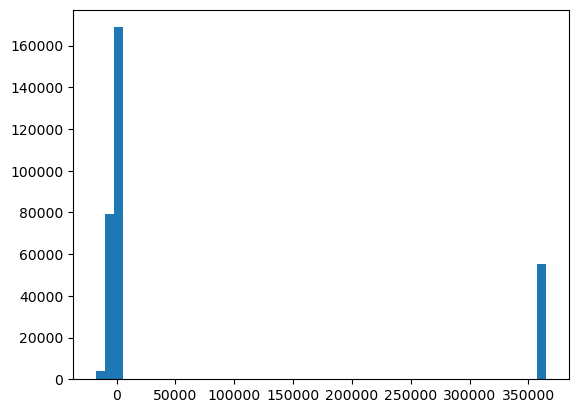

In [4]:
plt.hist(app_train['DAYS_EMPLOYED'], bins=50);
print(app_train['DAYS_EMPLOYED'].describe())
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace(365243, np.nan)

In [ ]:
app_train['is_train'] = 1
app_test['is_train'] = 0

app_train_target_value = app_train['TARGET']
app_all = pd.concat([app_train.drop(['TARGET'], axis=1), app_test], axis=0).reset_index(drop=True)
print('Combined Data Shape: ', app_all.shape)
app_all_train_test_indicator = app_all['is_train']
app_all.drop(['is_train'], axis = 1, inplace = True)
print('Final Combined Data Shape: ', app_all.shape)

Combined Data Shape: (356255, 122)
Final Combined Data Shape: (356255, 121)


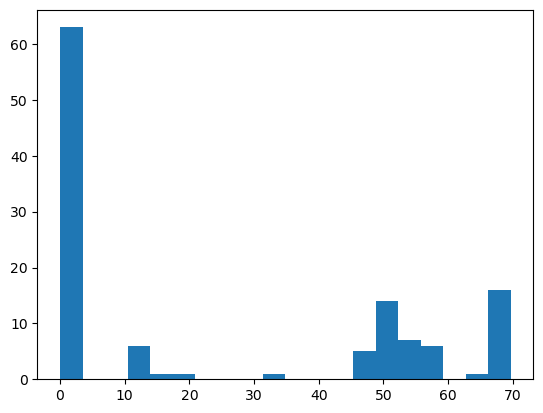

In [ ]:
missing_values = app_all.isnull().sum()
missing_values_percent = missing_values / len(app_all) * 100
plt.hist(missing_values_percent, bins=20);

In [7]:
missing_values_dtype = []
for i in range(len(missing_values)):
    missing_values_dtype.append(app_all[missing_values.index[i]].dtype)
missing_values_dtype
print(len(missing_values_dtype),len(missing_values_percent),len(missing_values),len(missing_values.index))

121 121 121 121


In [8]:
feature_drop_list = []
for i in range(len(missing_values_percent)):
    if missing_values_percent[i] >= 50: 
        feature_drop_list.append(missing_values.index[i])
print(feature_drop_list)

['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE']


In [9]:
app_all_drop = app_all.copy()
for i in range(len(feature_drop_list)):
    app_all_drop.drop(columns=feature_drop_list[i], inplace=True)

print('app_all shape:', app_all.shape)
print('Data Shape after dropping features with >40% missing values: ',app_all_drop.shape)

app_all shape: (356255, 121)
Data Shape after dropping features with >40% missing values:  (356255, 84)


In [ ]:
for col in app_all_drop.columns:
    if app_all_drop[col].isnull().sum() == 0:
        continue

    dt = app_all_drop[col].dtype

    if dt == 'float64':
        fill_val = app_all_drop[col].mean()

    elif pd.api.types.is_integer_dtype(dt):
        mode = app_all_drop[col].mode(dropna=True)
        fill_val = mode.iloc[0] if len(mode) > 0 else 0

    else:
        mode = app_all_drop[col].mode(dropna=True)
        fill_val = mode.iloc[0] if len(mode) > 0 else ''

    app_all_drop[col].fillna(fill_val, inplace=True)

print('Total missing after imputation:', app_all_drop.isnull().sum().sum())

Total missing after imputation: 0


## 2.2 Input Data Transformation

In [ ]:
object_cols = app_all_drop.select_dtypes('object').columns
object_nunique = app_all_drop[object_cols].nunique()
print(f'Object Columns Unique Values:\n{object_nunique}')
app_all_drop['CODE_GENDER'].replace('XNA', 'F', inplace=True)

Object Columns Unique Values:
NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
HOUSETYPE_MODE                 3
EMERGENCYSTATE_MODE            2
dtype: int64


In [ ]:

object_cols = app_all_drop.select_dtypes('object').columns
object_nunique = app_all_drop[object_cols].nunique()


binary_object_features = [col for col in object_nunique.index if object_nunique[col] == 2]
onehot_object_features = [col for col in object_nunique.index if object_nunique[col] > 2]

app_all_drop_encoded = app_all_drop.copy()


binary_mappings = {}
for col in binary_object_features:
    uniques = [u for u in pd.unique(app_all_drop_encoded[col]) if pd.notnull(u)]
    if len(uniques) == 2:
        sorted_uniques = sorted(uniques, key=lambda x: str(x))
        map_dict = {sorted_uniques[0]: 0, sorted_uniques[1]: 1}
    else:
        codes, uniques_fact = pd.factorize(app_all_drop_encoded[col])
        map_dict = {u: int(i) for i, u in enumerate(uniques_fact)}
    app_all_drop_encoded[col] = app_all_drop_encoded[col].map(map_dict).astype(np.uint8)
    binary_mappings[col] = map_dict

app_all_drop_encoded = pd.get_dummies(app_all_drop_encoded, columns=onehot_object_features,
                                      prefix=onehot_object_features, prefix_sep='__', dummy_na=False)

onehot_groups = {}
for col in onehot_object_features:
    pref = f"{col}__"
    onehot_groups[col] = [c for c in app_all_drop_encoded.columns if c.startswith(pref)]


def aggregate_feature_importances(fi_series, onehot_groups):
    fi = fi_series.copy()
    agg = {}
    for orig, dummies in onehot_groups.items():
        agg_val = fi.reindex(dummies).fillna(0).sum()
        agg[orig] = float(agg_val)
        fi = fi.drop(index=[c for c in dummies if c in fi.index], errors='ignore')
    for idx, val in fi.items():
        agg[idx] = float(val)
    return pd.Series(agg).sort_values(ascending=False)
print('Encoding complete. Encoded data shape:', app_all_drop_encoded.shape)

Encoding complete. Encoded data shape: (356255, 193)


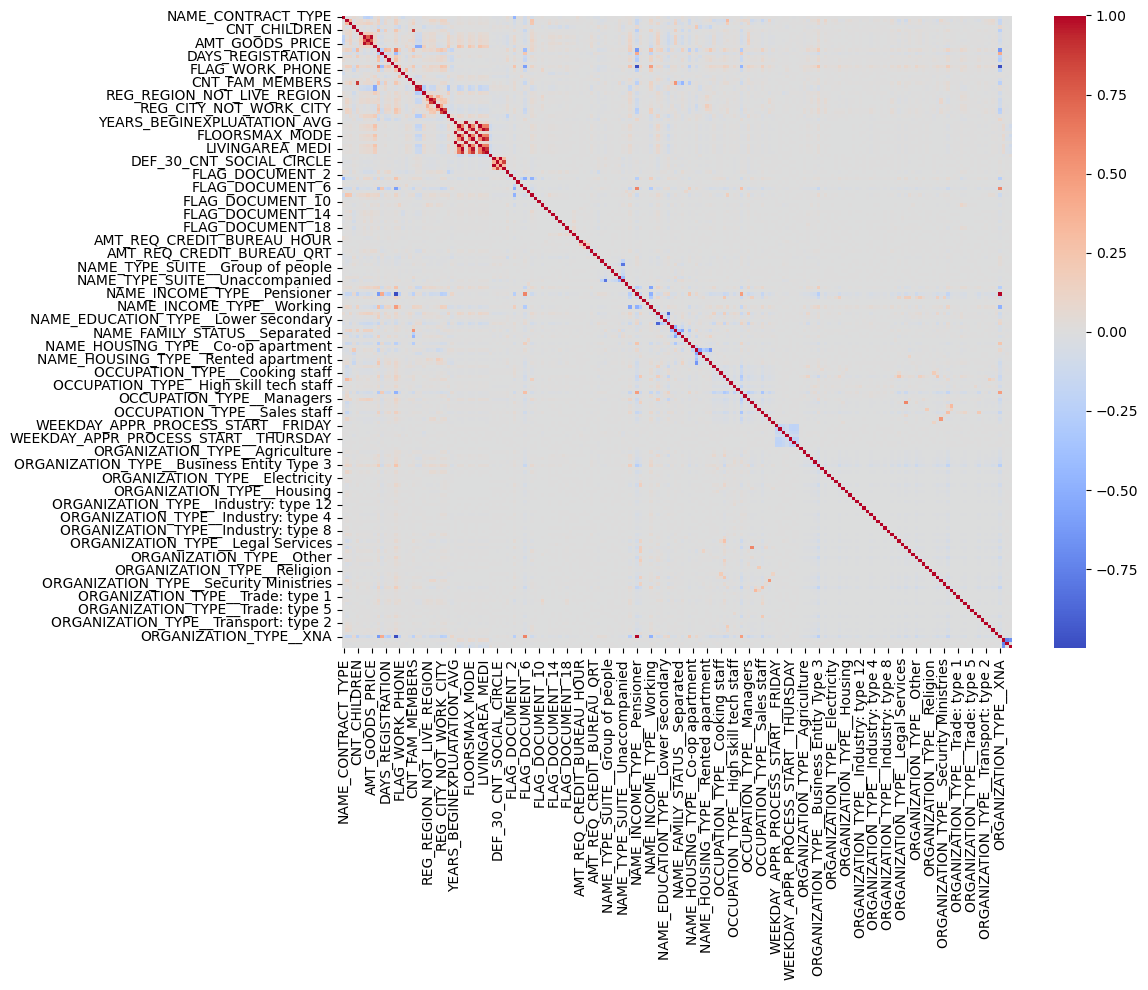

In [ ]:
corr_matrix = app_all_drop_encoded.drop('SK_ID_CURR', axis=1).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.tight_layout()
#plt.savefig('correlation_matrix.jpg', dpi=300)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib


cols_to_scale = app_all_drop_encoded.columns.drop('SK_ID_CURR')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_vals = scaler.fit_transform(app_all_drop_encoded[cols_to_scale].astype(float))


app_all_drop_encoded_transform = pd.DataFrame(scaled_vals, columns=cols_to_scale, index=app_all_drop_encoded.index)
#app_all_drop_encoded_transform.insert(0, 'SK_ID_CURR', app_all_drop_encoded['SK_ID_CURR'].values)

joblib.dump(scaler, 'minmax_scaler_app_all_drop_encoded.pkl')

print('Scaling complete. Scaled shape:', app_all_drop_encoded_transform.shape)

Scaling complete. Scaled shape: (356255, 192)


In [ ]:
train_encoded = app_all_drop_encoded_transform.loc[app_all_train_test_indicator == 1, :].reset_index(drop=True)
test_encoded  = app_all_drop_encoded_transform.loc[app_all_train_test_indicator == 0, :].reset_index(drop=True)

y = app_train_target_value.reset_index(drop=True)

from sklearn.model_selection import train_test_split

feature_cols = train_encoded.columns
X = train_encoded[feature_cols]

X_train_encoded, X_val_encoded, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train input shape:', X_train_encoded.shape)
print('Validation input shape:', X_val_encoded.shape)
print('Train labels shape:', y_train.shape)
print('Validation labels shape:', y_val.shape)

X_train_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in X_train_encoded.columns]
X_val_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in X_val_encoded.columns]
test_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in test_encoded.columns]

Train input shape: (246008, 192)
Validation input shape: (61503, 192)
Train labels shape: (246008,)
Validation labels shape: (61503,)


In [ ]:
from sklearn.linear_model import LogisticRegression

clf_basline_LogisticRegression = LogisticRegression(C = 0.0001)
clf_basline_LogisticRegression.fit(X_train_encoded, y_train)

log_reg_pred = clf_basline_LogisticRegression.predict_proba(test_encoded)[:, 1]

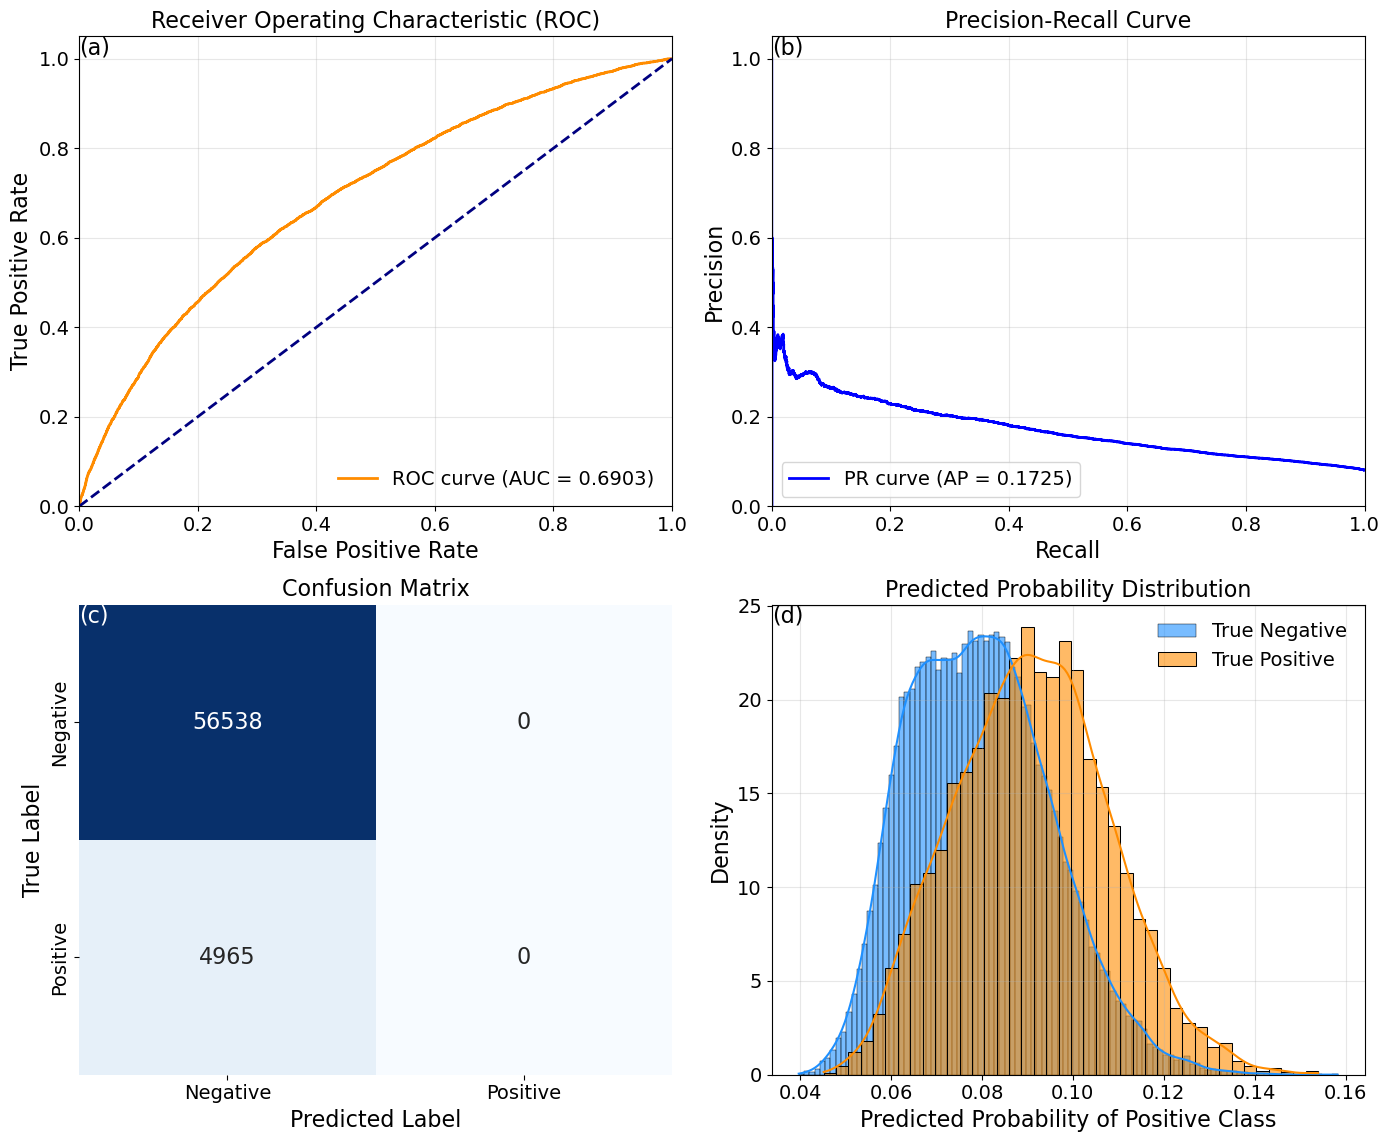

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification


y_true = y_val.values if hasattr(y_val, "values") else np.array(y_val)
y_score = clf_basline_LogisticRegression.predict_proba(X_val_encoded)[:, 1]


fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)


precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)


y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
clf_report = classification_report(y_true, y_pred, digits=4)



fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve 
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=16)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=16)
axes[0, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=16)
axes[0, 0].legend(loc="lower right", fontsize=14,frameon=False)
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].grid(alpha=0.3)
xcor_max=axes[0, 0].get_xlim()[1];xcor_min=axes[0, 0].get_xlim()[0]
ycor_max=axes[0, 0].get_ylim()[1];ycor_min=axes[0, 0].get_ylim()[0]
axes[0, 0].text(xcor_min,ycor_max,"(a)",fontsize=16,ha='left',va='top')

# 2. Precision-Recall Curve
axes[0, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_prec:.4f})')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall', fontsize=16)
axes[0, 1].set_ylabel('Precision', fontsize=16)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=16)
axes[0, 1].legend(loc="lower left", fontsize=14)
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].grid(alpha=0.3)
xcor_max=axes[0, 1].get_xlim()[1];xcor_min=axes[0, 1].get_xlim()[0]
ycor_max=axes[0, 1].get_ylim()[1];ycor_min=axes[0, 1].get_ylim()[0]
axes[0, 1].text(xcor_min,ycor_max,"(b)",fontsize=16,ha='left',va='top')

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            annot_kws={"size": 16})
axes[1, 0].set_title('Confusion Matrix', fontsize=16)
axes[1, 0].set_xlabel('Predicted Label', fontsize=16)
axes[1, 0].set_ylabel('True Label', fontsize=16)
axes[1, 0].set_xticklabels(['Negative', 'Positive'],fontsize=14)
axes[1, 0].set_yticklabels(['Negative', 'Positive'], fontsize=14)
xcor_max=axes[1, 0].get_xlim()[1];xcor_min=axes[1, 0].get_xlim()[0]
ycor_max=axes[1, 0].get_ylim()[1];ycor_min=axes[1, 0].get_ylim()[0]
axes[1, 0].text(xcor_min,ycor_max,"(c)",fontsize=16,ha='left',va='top',color='white')

# 4. Predicted Probability Histograms
sns.histplot(y_score[y_true == 0], color="dodgerblue", ax=axes[1, 1], label='True Negative', alpha=0.6, kde=True, stat='density', common_norm=False)
sns.histplot(y_score[y_true == 1], color="darkorange", ax=axes[1, 1], label='True Positive', alpha=0.6, kde=True, stat='density', common_norm=False)
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=16)
axes[1, 1].set_xlabel('Predicted Probability of Positive Class', fontsize=16)
axes[1, 1].set_ylabel('Density', fontsize=16)
axes[1, 1].legend(fontsize=14,frameon=False)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
xcor_max=axes[1, 1].get_xlim()[1];xcor_min=axes[1, 1].get_xlim()[0]
ycor_max=axes[1, 1].get_ylim()[1];ycor_min=axes[1, 1].get_ylim()[0]
axes[1, 1].text(xcor_min,ycor_max,"(d)",fontsize=16,ha='left',va='top')

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("output/logistic_regression_evaluation_plots.jpg", dpi=600)
plt.show()

In [18]:
sub_log_baseline = pd.DataFrame()
sub_log_baseline['SK_ID_CURR'] = app_all_drop_encoded['SK_ID_CURR'][app_all_train_test_indicator == 0]
sub_log_baseline['TARGET'] = log_reg_pred
#sub_log_baseline.to_csv('output/submission_logistic_regression_baseline.csv', index=False)

In [ ]:
from sklearn.ensemble import RandomForestClassifier


clf_basline_random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)
clf_basline_random_forest.fit(X_train_encoded, y_train)
clf_random_pred = clf_basline_random_forest.predict_proba(test_encoded)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    7.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


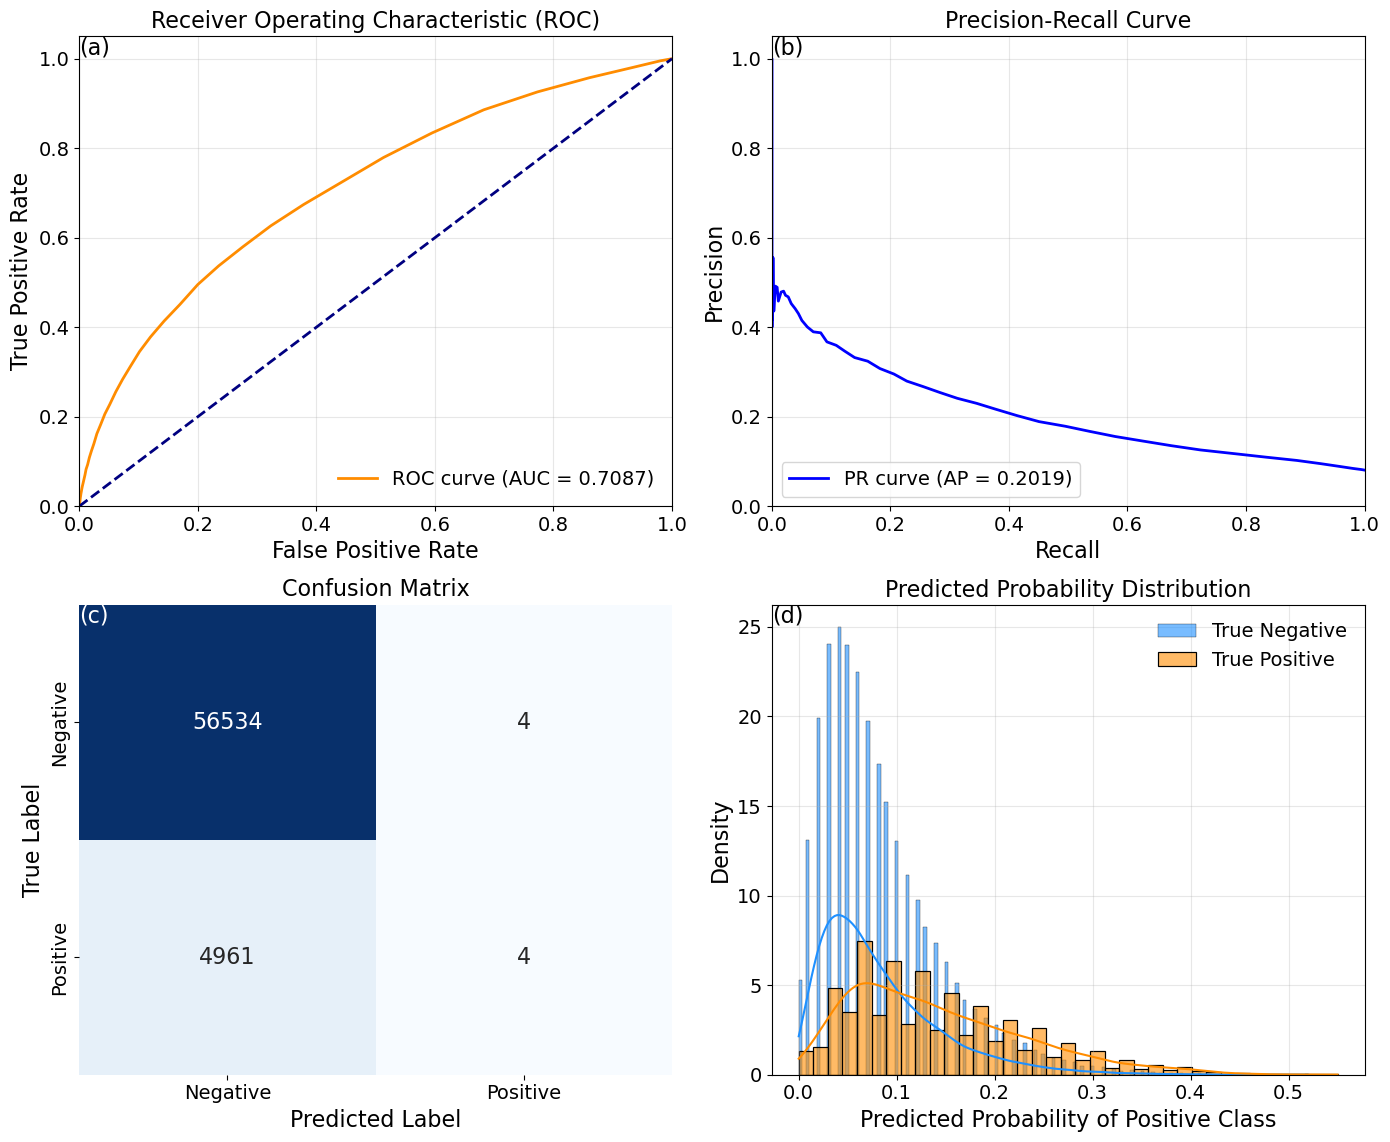

In [ ]:
y_true = y_val.values if hasattr(y_val, "values") else np.array(y_val)
y_score = clf_basline_random_forest.predict_proba(X_val_encoded)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)


y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
clf_report = classification_report(y_true, y_pred, digits=4)



fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=16)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=16)
axes[0, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=16)
axes[0, 0].legend(loc="lower right", fontsize=14,frameon=False)
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].grid(alpha=0.3)
xcor_max=axes[0, 0].get_xlim()[1];xcor_min=axes[0, 0].get_xlim()[0]
ycor_max=axes[0, 0].get_ylim()[1];ycor_min=axes[0, 0].get_ylim()[0]
axes[0, 0].text(xcor_min,ycor_max,"(a)",fontsize=16,ha='left',va='top')

# 2. Precision-Recall Curve 
axes[0, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_prec:.4f})')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall', fontsize=16)
axes[0, 1].set_ylabel('Precision', fontsize=16)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=16)
axes[0, 1].legend(loc="lower left", fontsize=14)
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].grid(alpha=0.3)
xcor_max=axes[0, 1].get_xlim()[1];xcor_min=axes[0, 1].get_xlim()[0]
ycor_max=axes[0, 1].get_ylim()[1];ycor_min=axes[0, 1].get_ylim()[0]
axes[0, 1].text(xcor_min,ycor_max,"(b)",fontsize=16,ha='left',va='top')

# 3. Confusion Matrix 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            annot_kws={"size": 16})
axes[1, 0].set_title('Confusion Matrix', fontsize=16)
axes[1, 0].set_xlabel('Predicted Label', fontsize=16)
axes[1, 0].set_ylabel('True Label', fontsize=16)
axes[1, 0].set_xticklabels(['Negative', 'Positive'],fontsize=14)
axes[1, 0].set_yticklabels(['Negative', 'Positive'], fontsize=14)
xcor_max=axes[1, 0].get_xlim()[1];xcor_min=axes[1, 0].get_xlim()[0]
ycor_max=axes[1, 0].get_ylim()[1];ycor_min=axes[1, 0].get_ylim()[0]
axes[1, 0].text(xcor_min,ycor_max,"(c)",fontsize=16,ha='left',va='top',color='white')

# 4. Predicted Probability Histograms 
sns.histplot(y_score[y_true == 0], color="dodgerblue", ax=axes[1, 1], label='True Negative', alpha=0.6, kde=True, stat='density', common_norm=False)
sns.histplot(y_score[y_true == 1], color="darkorange", ax=axes[1, 1], label='True Positive', alpha=0.6, kde=True, stat='density', common_norm=False)
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=16)
axes[1, 1].set_xlabel('Predicted Probability of Positive Class', fontsize=16)
axes[1, 1].set_ylabel('Density', fontsize=16)
axes[1, 1].legend(fontsize=14,frameon=False)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
xcor_max=axes[1, 1].get_xlim()[1];xcor_min=axes[1, 1].get_xlim()[0]
ycor_max=axes[1, 1].get_ylim()[1];ycor_min=axes[1, 1].get_ylim()[0]
axes[1, 1].text(xcor_min,ycor_max,"(d)",fontsize=16,ha='left',va='top')

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("output/random_forest_evaluation_plots.jpg", dpi=600)

In [21]:
sub_log_baseline = pd.DataFrame()
sub_log_baseline['SK_ID_CURR'] = app_all_drop_encoded['SK_ID_CURR'][app_all_train_test_indicator == 0]
sub_log_baseline['TARGET'] = clf_random_pred
#sub_log_baseline.to_csv('output/submission_random_forest_baseline.csv', index=False)

In [93]:
from lightgbm import LGBMClassifier

clf_basline_LGBMClassifier = LGBMClassifier(
                nthread=4,
                n_estimators=2000,
                learning_rate=0.02,
                max_depth = 11,
                num_leaves=58,
                colsample_bytree=0.613,
                subsample=0.708,
                max_bin=407,
                reg_alpha=3.564,
                reg_lambda=4.930,
                min_child_weight= 6,
                min_child_samples=165,
                silent=-1,
                verbose= 100,
                )


clf_basline_LGBMClassifier.fit(X_train_encoded, y_train)

predictions = clf_basline_LGBMClassifier.predict_proba(test_encoded)[:, 1]

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.897525
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.589284
[LightGBM] [Debug] init for col-wise cost 0.009445 seconds, init for row-wise cost 0.030809 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 7360
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 168
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Debug] Trained a tree with lea

[LightGBM] [Warning] Unknown parameter: silent


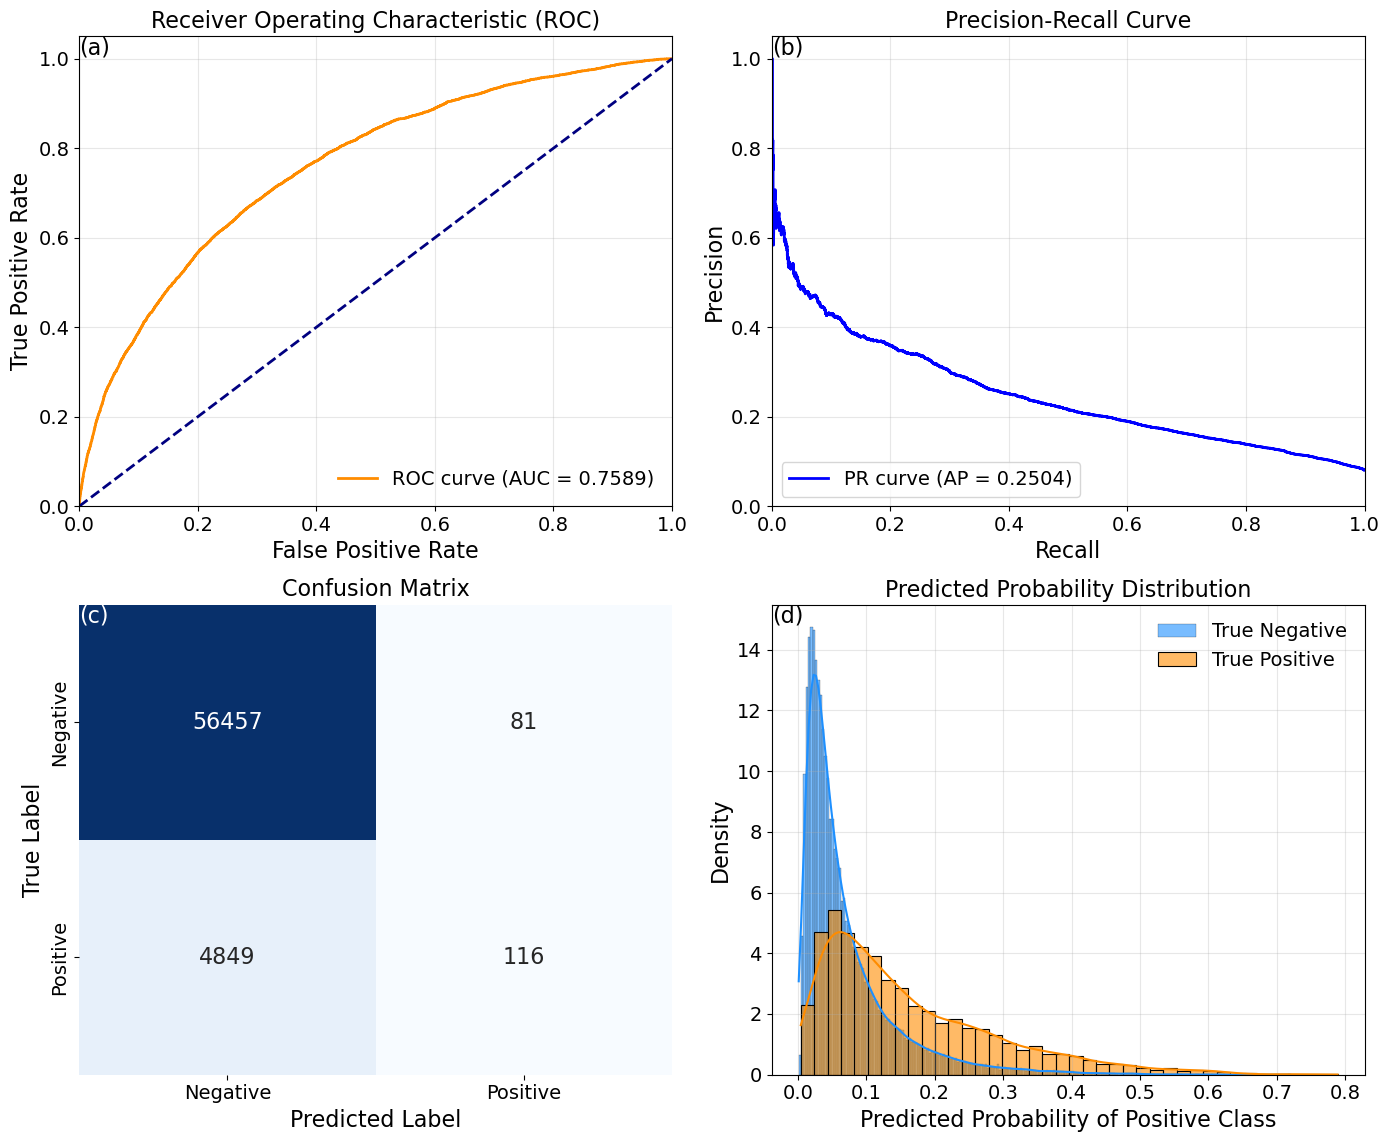

In [ ]:
y_true = y_val.values if hasattr(y_val, "values") else np.array(y_val)
y_score = clf_basline_LGBMClassifier.predict_proba(X_val_encoded)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)

y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
clf_report = classification_report(y_true, y_pred, digits=4)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve 
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=16)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=16)
axes[0, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=16)
axes[0, 0].legend(loc="lower right", fontsize=14,frameon=False)
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].grid(alpha=0.3)
xcor_max=axes[0, 0].get_xlim()[1];xcor_min=axes[0, 0].get_xlim()[0]
ycor_max=axes[0, 0].get_ylim()[1];ycor_min=axes[0, 0].get_ylim()[0]
axes[0, 0].text(xcor_min,ycor_max,"(a)",fontsize=16,ha='left',va='top')

# 2. Precision-Recall Curve
axes[0, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_prec:.4f})')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall', fontsize=16)
axes[0, 1].set_ylabel('Precision', fontsize=16)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=16)
axes[0, 1].legend(loc="lower left", fontsize=14)
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].grid(alpha=0.3)
xcor_max=axes[0, 1].get_xlim()[1];xcor_min=axes[0, 1].get_xlim()[0]
ycor_max=axes[0, 1].get_ylim()[1];ycor_min=axes[0, 1].get_ylim()[0]
axes[0, 1].text(xcor_min,ycor_max,"(b)",fontsize=16,ha='left',va='top')

# 3. Confusion Matrix 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            annot_kws={"size": 16})
axes[1, 0].set_title('Confusion Matrix', fontsize=16)
axes[1, 0].set_xlabel('Predicted Label', fontsize=16)
axes[1, 0].set_ylabel('True Label', fontsize=16)
axes[1, 0].set_xticklabels(['Negative', 'Positive'],fontsize=14)
axes[1, 0].set_yticklabels(['Negative', 'Positive'], fontsize=14)
xcor_max=axes[1, 0].get_xlim()[1];xcor_min=axes[1, 0].get_xlim()[0]
ycor_max=axes[1, 0].get_ylim()[1];ycor_min=axes[1, 0].get_ylim()[0]
axes[1, 0].text(xcor_min,ycor_max,"(c)",fontsize=16,ha='left',va='top',color='white')

# 4. Predicted Probability Histograms
sns.histplot(y_score[y_true == 0], color="dodgerblue", ax=axes[1, 1], label='True Negative', alpha=0.6, kde=True, stat='density', common_norm=False)
sns.histplot(y_score[y_true == 1], color="darkorange", ax=axes[1, 1], label='True Positive', alpha=0.6, kde=True, stat='density', common_norm=False)
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=16)
axes[1, 1].set_xlabel('Predicted Probability of Positive Class', fontsize=16)
axes[1, 1].set_ylabel('Density', fontsize=16)
axes[1, 1].legend(fontsize=14,frameon=False)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
xcor_max=axes[1, 1].get_xlim()[1];xcor_min=axes[1, 1].get_xlim()[0]
ycor_max=axes[1, 1].get_ylim()[1];ycor_min=axes[1, 1].get_ylim()[0]
axes[1, 1].text(xcor_min,ycor_max,"(d)",fontsize=16,ha='left',va='top')

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("output/lgbm_evaluation_plots.jpg", dpi=600)

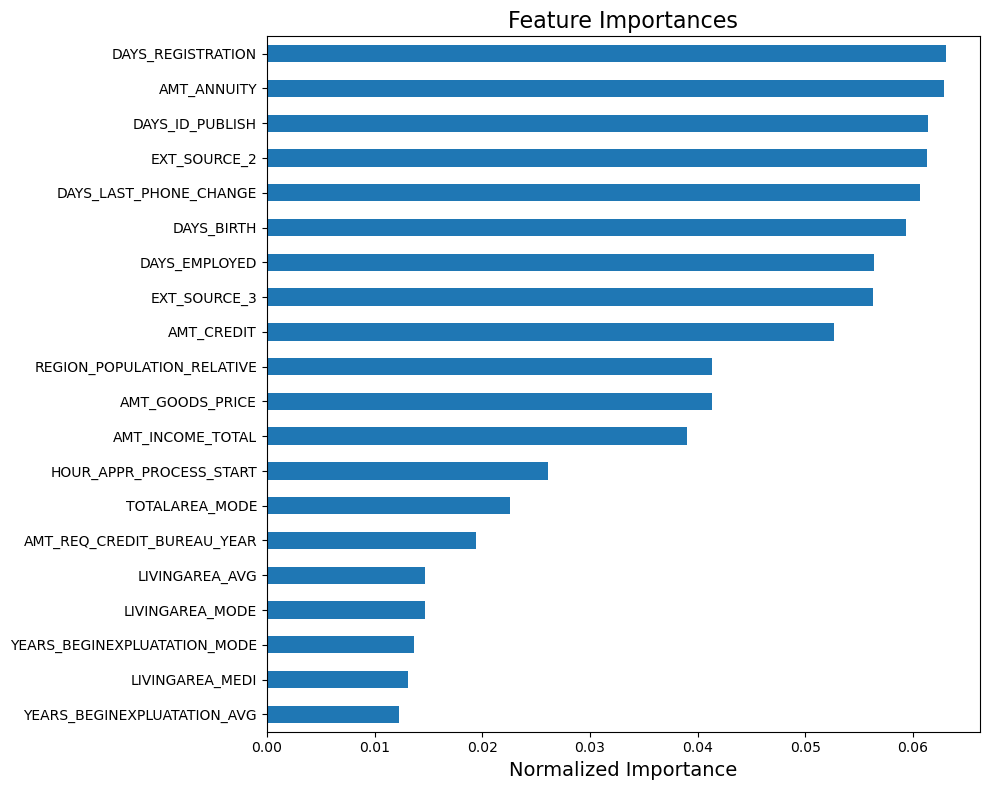

In [ ]:
lgbm_feature_importances = pd.Series(clf_basline_LGBMClassifier.feature_importances_, index=X_train_encoded.columns)
normalized_lgbm_feature_importances = lgbm_feature_importances / lgbm_feature_importances.sum()
lgbm_feature_importances_agg = aggregate_feature_importances(normalized_lgbm_feature_importances, onehot_groups)
plt.figure(figsize=(10, 8))
lgbm_feature_importances_agg.sort_values(ascending=True).tail(20).plot.barh()
plt.title('Feature Importances', fontsize=16)
plt.xlabel('Normalized Importance', fontsize=14)
plt.tight_layout()

threshold_10_percentile = lgbm_feature_importances_agg.quantile(0.1)
threshold_90_percentile = lgbm_feature_importances_agg.quantile(0.9)
bottom_10_feature_names = lgbm_feature_importances_agg[lgbm_feature_importances_agg <= threshold_10_percentile].index.tolist()
bottom_90_feature_names = lgbm_feature_importances_agg[lgbm_feature_importances_agg > threshold_90_percentile].index.tolist()

#plt.savefig("output/lgbm_feature_importances.jpg", dpi=300)

In [25]:
sub_log_baseline = pd.DataFrame()
sub_log_baseline['SK_ID_CURR'] = app_all_drop_encoded['SK_ID_CURR'][app_all_train_test_indicator == 0]
sub_log_baseline['TARGET'] = predictions
#sub_log_baseline.to_csv('output/submission_lgbm_baseline.csv', index=False)

Text(0.5, 1.0, 'Important Feature Correlation Heatmap')

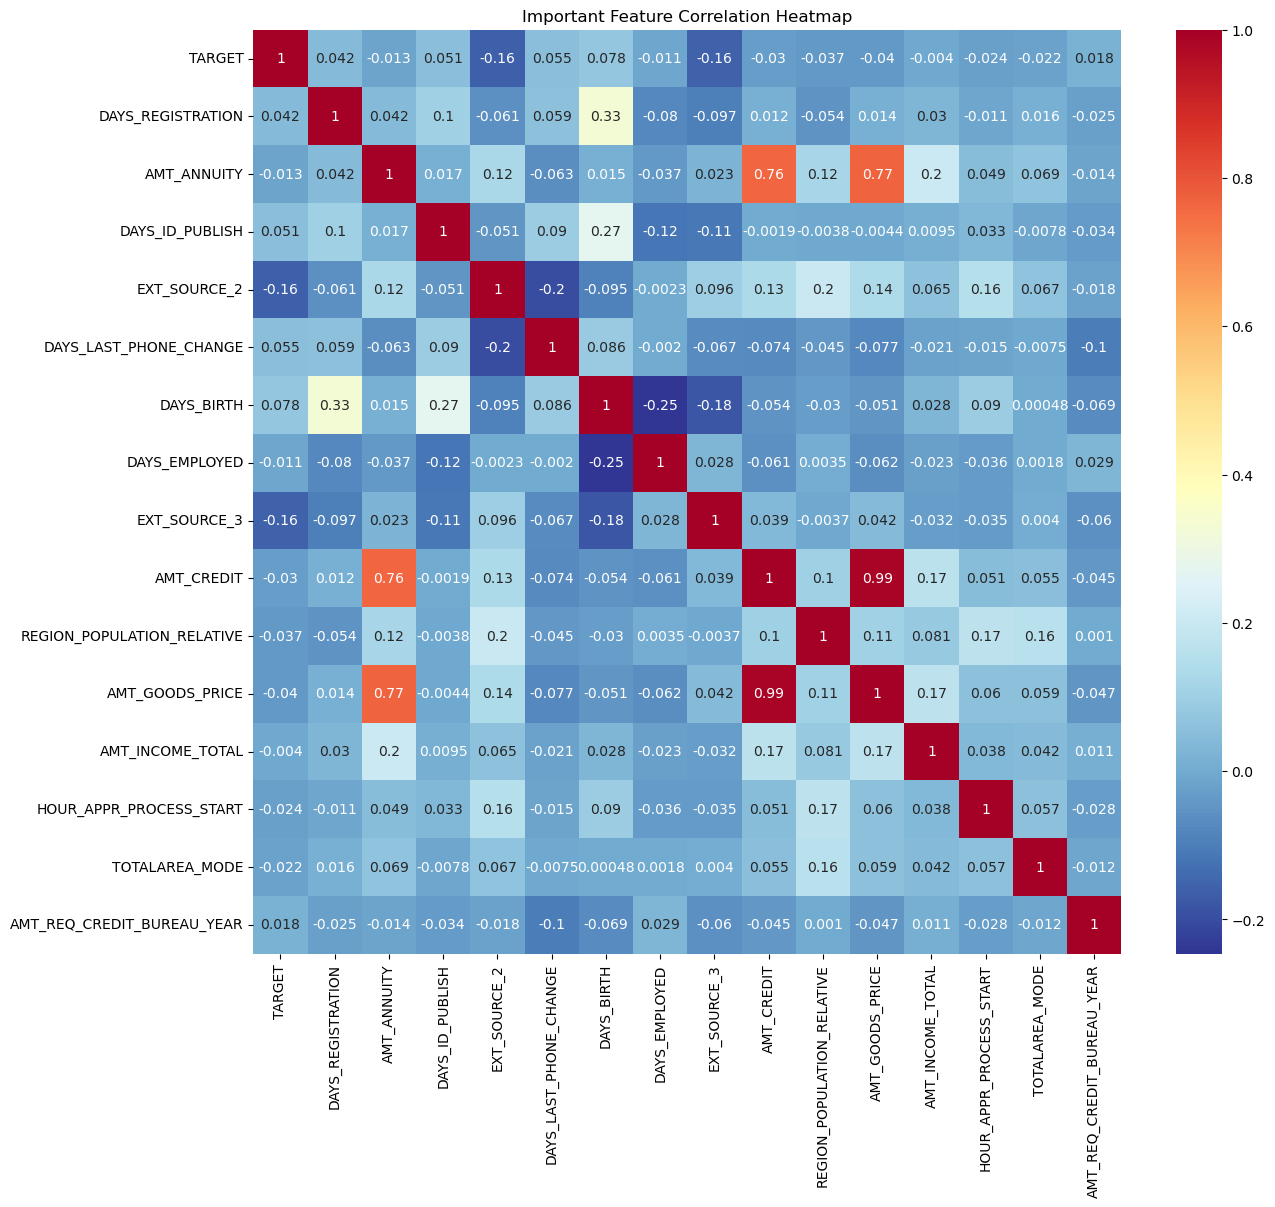

In [26]:
ext_data = app_all_drop_encoded_transform[bottom_90_feature_names]
ext_data = pd.concat([app_train['TARGET'], ext_data] , axis=1)
ext_data_corrs = ext_data.corr()
plt.figure(figsize = (14, 12))
# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, annot = True)
plt.title('Important Feature Correlation Heatmap')
#plt.savefig('output/important_feature_correlation_heatmap.jpg', dpi=300)

In [ ]:
import process_extra_data
all_agg_data = process_extra_data.load_and_aggregate_all_data(data_dir='data/')
if all_agg_data:
    bureau_features = all_agg_data['bureau_agg']
    prev_app_features = all_agg_data['prev_agg']
    print(bureau_features.head())
    print(prev_app_features.shape)

--- 开始加载数据 ---
--- 数据加载完毕，开始聚合 ---
Bureau data 聚合完毕。
Previous application 聚合完毕。
POS_CASH_balance 聚合完毕。
Installments 聚合完毕。
Credit card 聚合完毕。
--- 所有聚合完成 ---
   SK_ID_CURR  BUREAU_SK_ID_BUREAU_COUNT  BUREAU_DAYS_CREDIT_MIN  \
0      100001                          7                   -1572   
1      100002                          8                   -1437   
2      100003                          4                   -2586   
3      100004                          2                   -1326   
4      100005                          3                    -373   

   BUREAU_DAYS_CREDIT_MAX  BUREAU_DAYS_CREDIT_MEAN  \
0                     -49              -735.000000   
1                    -103              -874.000000   
2                    -606             -1400.750000   
3                    -408              -867.000000   
4                     -62              -190.666667   

   BUREAU_CREDIT_DAY_OVERDUE_MIN  BUREAU_CREDIT_DAY_OVERDUE_MAX  \
0                              0            

In [97]:
pos_cash_features = all_agg_data['pos_bal_agg']
credit_card_features = all_agg_data['card_bal_agg']
installments_features = all_agg_data['install_agg']
print(pos_cash_features.shape)
print(credit_card_features.shape)
print(installments_features.shape)
print(bureau_features.shape)
print(prev_app_features.shape)

app_all_drop_encoded_extra_features = app_all_drop_encoded.merge(
    bureau_features, on='SK_ID_CURR', how='left'
).merge(
    prev_app_features, on='SK_ID_CURR', how='left'
).merge(
    pos_cash_features, on='SK_ID_CURR', how='left'
).merge(
    credit_card_features, on='SK_ID_CURR', how='left'
).merge(
    installments_features, on='SK_ID_CURR', how='left'
)

print(app_all_drop_encoded_extra_features.shape)
print(app_all_drop_encoded.shape)

(337252, 45)
(103558, 69)
(339587, 59)
(305811, 149)
(338857, 80)
(356255, 591)
(356255, 193)


In [98]:
app_all_drop_encoded_extra_features.replace([np.inf, -np.inf], np.nan, inplace=True)
print("已将所有 Inf 值替换为 NaN。")

已将所有 Inf 值替换为 NaN。


In [ ]:

cols_to_scale = app_all_drop_encoded_extra_features.columns.drop('SK_ID_CURR')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_vals = scaler.fit_transform(app_all_drop_encoded_extra_features[cols_to_scale].astype(float))

app_all_drop_encoded_extra_features_transform = pd.DataFrame(scaled_vals, columns=cols_to_scale, index=app_all_drop_encoded_extra_features.index)

print('Scaling complete. Scaled shape:', app_all_drop_encoded_extra_features_transform.shape)

Scaling complete. Scaled shape: (356255, 590)


In [ ]:

train_encoded = app_all_drop_encoded_extra_features_transform.loc[app_all_train_test_indicator == 1, :].reset_index(drop=True)
test_encoded  = app_all_drop_encoded_extra_features_transform.loc[app_all_train_test_indicator == 0, :].reset_index(drop=True)


y = app_train_target_value.reset_index(drop=True)

from sklearn.model_selection import train_test_split

feature_cols = train_encoded.columns
X = train_encoded[feature_cols]

X_train_encoded, X_val_encoded, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train input shape:', X_train_encoded.shape)
print('Validation input shape:', X_val_encoded.shape)
print('Train labels shape:', y_train.shape)
print('Validation labels shape:', y_val.shape)

X_train_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in X_train_encoded.columns]
X_val_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in X_val_encoded.columns]
test_encoded.columns = [re.sub(r'[\[\]{}":,\s<>]', '_', col) for col in test_encoded.columns]

Train input shape: (246008, 590)
Validation input shape: (61503, 590)
Train labels shape: (246008,)
Validation labels shape: (61503,)


In [101]:
clf_basline_LGBMClassifier = LGBMClassifier(
                nthread=4,
                n_estimators=2000,
                learning_rate=0.02,
                max_depth = 11,
                num_leaves=58,
                colsample_bytree=0.613,
                subsample=0.708,
                max_bin=407,
                reg_alpha=3.564,
                reg_lambda=4.930,
                min_child_weight= 6,
                min_child_samples=165,
                silent=-1,
                verbose= 100,
                )


clf_basline_LGBMClassifier.fit(X_train_encoded, y_train)

predictions = clf_basline_LGBMClassifier.predict_proba(test_encoded)[:, 1]

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.808995
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.390276
[LightGBM] [Debug] init for col-wise cost 0.038005 seconds, init for row-wise cost 0.256520 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.278893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130449
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 566
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 58 and depth = 10
[LightGBM] [Debug] 

[LightGBM] [Warning] Unknown parameter: silent


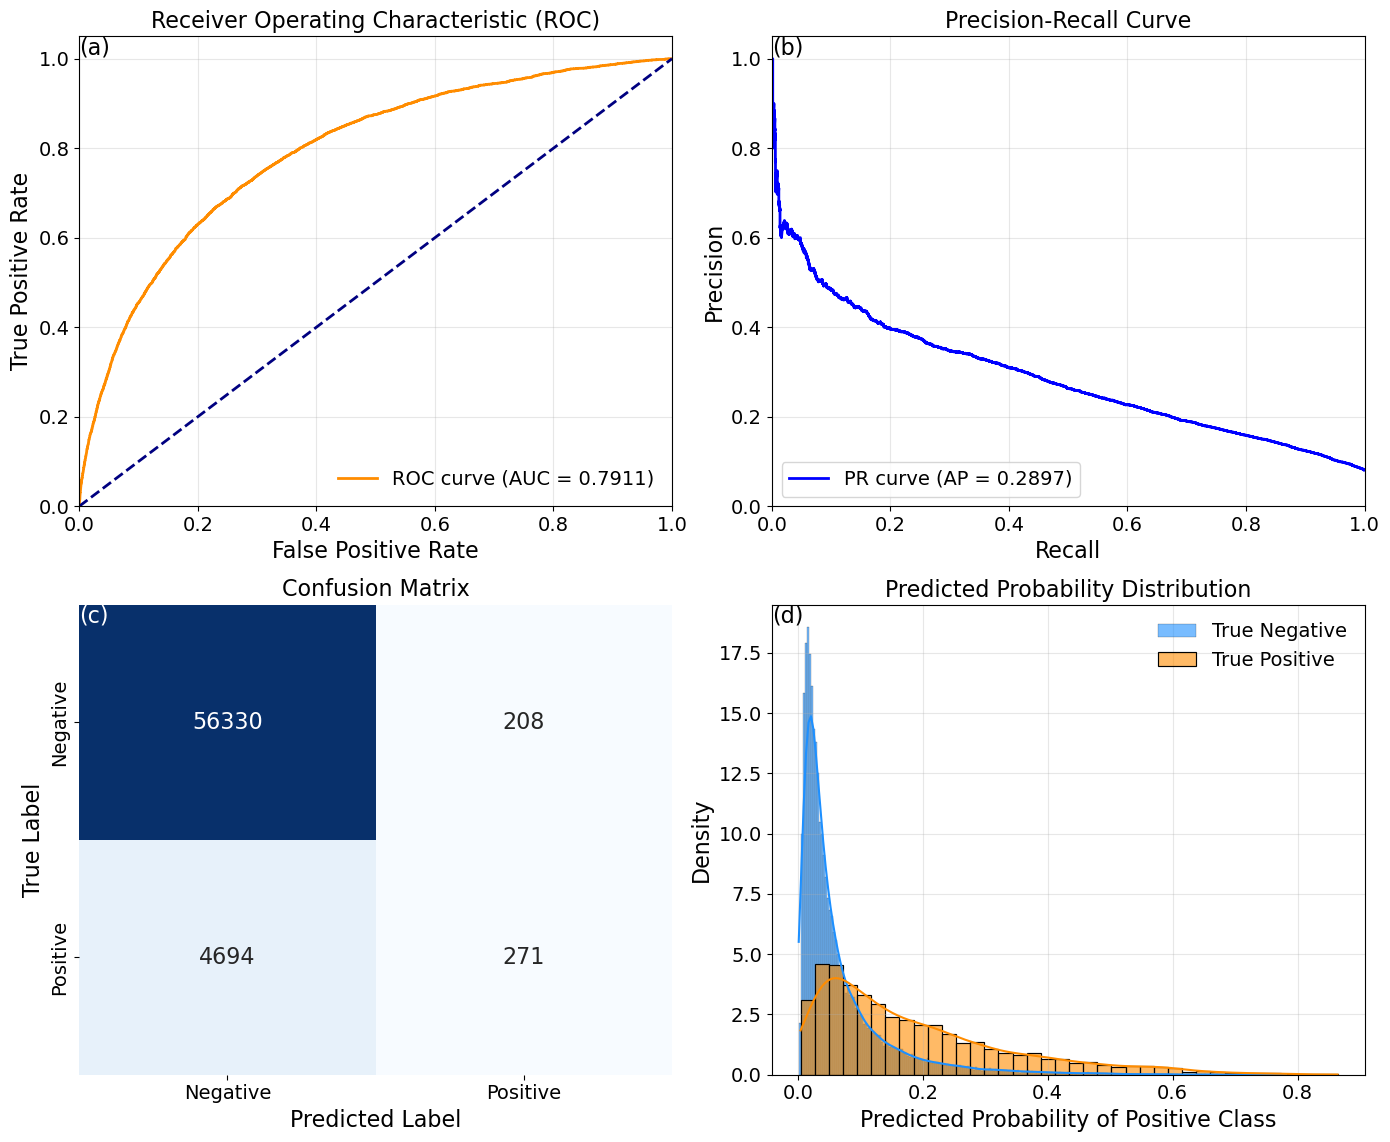

In [ ]:
y_true = y_val.values if hasattr(y_val, "values") else np.array(y_val)
y_score = clf_basline_LGBMClassifier.predict_proba(X_val_encoded)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# PR
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)


y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
clf_report = classification_report(y_true, y_pred, digits=4)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve 
axes[0, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=16)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=16)
axes[0, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=16)
axes[0, 0].legend(loc="lower right", fontsize=14,frameon=False)
axes[0, 0].tick_params(axis='both', which='major', labelsize=14)
axes[0, 0].grid(alpha=0.3)
xcor_max=axes[0, 0].get_xlim()[1];xcor_min=axes[0, 0].get_xlim()[0]
ycor_max=axes[0, 0].get_ylim()[1];ycor_min=axes[0, 0].get_ylim()[0]
axes[0, 0].text(xcor_min,ycor_max,"(a)",fontsize=16,ha='left',va='top')

# 2. Precision-Recall Curve
axes[0, 1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_prec:.4f})')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Recall', fontsize=16)
axes[0, 1].set_ylabel('Precision', fontsize=16)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=16)
axes[0, 1].legend(loc="lower left", fontsize=14)
axes[0, 1].tick_params(axis='both', which='major', labelsize=14)
axes[0, 1].grid(alpha=0.3)
xcor_max=axes[0, 1].get_xlim()[1];xcor_min=axes[0, 1].get_xlim()[0]
ycor_max=axes[0, 1].get_ylim()[1];ycor_min=axes[0, 1].get_ylim()[0]
axes[0, 1].text(xcor_min,ycor_max,"(b)",fontsize=16,ha='left',va='top')

# 3. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], cbar=False,
            annot_kws={"size": 16})
axes[1, 0].set_title('Confusion Matrix', fontsize=16)
axes[1, 0].set_xlabel('Predicted Label', fontsize=16)
axes[1, 0].set_ylabel('True Label', fontsize=16)
axes[1, 0].set_xticklabels(['Negative', 'Positive'],fontsize=14)
axes[1, 0].set_yticklabels(['Negative', 'Positive'], fontsize=14)
xcor_max=axes[1, 0].get_xlim()[1];xcor_min=axes[1, 0].get_xlim()[0]
ycor_max=axes[1, 0].get_ylim()[1];ycor_min=axes[1, 0].get_ylim()[0]
axes[1, 0].text(xcor_min,ycor_max,"(c)",fontsize=16,ha='left',va='top',color='white')

# 4. Predicted Probability Histograms
sns.histplot(y_score[y_true == 0], color="dodgerblue", ax=axes[1, 1], label='True Negative', alpha=0.6, kde=True, stat='density', common_norm=False)
sns.histplot(y_score[y_true == 1], color="darkorange", ax=axes[1, 1], label='True Positive', alpha=0.6, kde=True, stat='density', common_norm=False)
axes[1, 1].set_title('Predicted Probability Distribution', fontsize=16)
axes[1, 1].set_xlabel('Predicted Probability of Positive Class', fontsize=16)
axes[1, 1].set_ylabel('Density', fontsize=16)
axes[1, 1].legend(fontsize=14,frameon=False)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='both', which='major', labelsize=14)
xcor_max=axes[1, 1].get_xlim()[1];xcor_min=axes[1, 1].get_xlim()[0]
ycor_max=axes[1, 1].get_ylim()[1];ycor_min=axes[1, 1].get_ylim()[0]
axes[1, 1].text(xcor_min,ycor_max,"(d)",fontsize=16,ha='left',va='top')

plt.tight_layout(rect=[0, 0, 1, 0.96])
#plt.savefig("output/lgbm_evaluation_with_extra_features_plots.jpg", dpi=600)

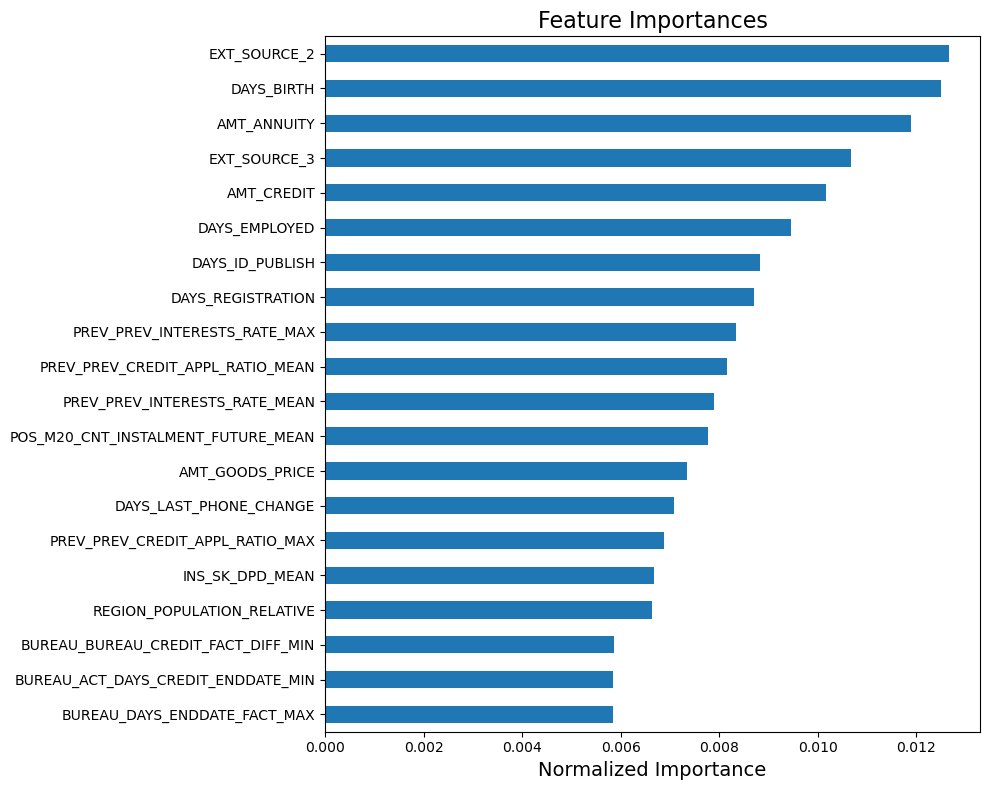

In [103]:
lgbm_feature_importances = pd.Series(clf_basline_LGBMClassifier.feature_importances_, index=X_train_encoded.columns)
normalized_lgbm_feature_importances = lgbm_feature_importances / lgbm_feature_importances.sum()
lgbm_feature_importances_agg = aggregate_feature_importances(normalized_lgbm_feature_importances, onehot_groups)
plt.figure(figsize=(10, 8))
lgbm_feature_importances_agg.sort_values(ascending=True).tail(20).plot.barh()
plt.title('Feature Importances', fontsize=16)
plt.xlabel('Normalized Importance', fontsize=14)
plt.tight_layout()
#plt.savefig("output/feature_importances_with_aggregated.jpg", dpi=600)

In [ ]:
import numpy as np


all_features_importances = pd.Series(clf_basline_LGBMClassifier.feature_importances_, index=X_train_encoded.columns)
normalized_lgbm_feature_importances = all_features_importances / all_features_importances.sum()


all_features_sorted = normalized_lgbm_feature_importances.sort_values(ascending=False)


total_features_count = len(all_features_sorted)
top_50_percent_count = int(np.ceil(total_features_count * 0.5)) 


top_50_features = all_features_sorted.head(top_50_percent_count)

new_feature_prefixes = [
    'BUREAU_', 
    'PREV_', 
    'POS_', 
    'INS_', 
    'CARD_'
]


is_new_feature = top_50_features.index.str.startswith(tuple(new_feature_prefixes))
new_features_in_top_50 = top_50_features[is_new_feature]

print("--- 特征重要性分析 (Top 50%) ---")
print(f"总特征数: {total_features_count}")
print(f"Top 50% 阈值 (特征数): {top_50_percent_count}")
print(f"Top 50% 特征中，有多少是新增的聚合特征: {len(new_features_in_top_50)}")
print("-" * 30)

if len(new_features_in_top_50) > 0:
    print(f"✅ 恭喜！有 {len(new_features_in_top_50)} 个新增特征进入了Top 50%。")
    print("以下是它们及其重要性 (已归一化):")
    print(new_features_in_top_50)
else:
    print("❌ 遗憾，没有新增特征进入Top 50%。")

--- 特征重要性分析 (Top 50%) ---
总特征数: 590
Top 50% 阈值 (特征数): 295
Top 50% 特征中，有多少是新增的聚合特征: 258
------------------------------
✅ 恭喜！有 258 个新增特征进入了Top 50%。
以下是它们及其重要性 (已归一化):
PREV_PREV_INTERESTS_RATE_MAX             0.008347
PREV_PREV_CREDIT_APPL_RATIO_MEAN         0.008163
PREV_PREV_INTERESTS_RATE_MEAN            0.007891
POS_M20_CNT_INSTALMENT_FUTURE_MEAN       0.007768
PREV_PREV_CREDIT_APPL_RATIO_MAX          0.006872
                                           ...   
CARD_M3_AMT_PAYMENT_TOTAL_CURRENT_MAX    0.000878
CARD_AMT_DRAWINGS_POS_CURRENT_SUM        0.000869
INS_NUM_INSTALMENT_VERSION_NUNIQUE       0.000851
CARD_M3_AMT_DRAWINGS_ATM_CURRENT_SUM     0.000843
CARD_AMT_DRAWINGS_CURRENT_SUM            0.000843
Length: 258, dtype: float64


In [ ]:

all_features_importances = pd.Series(clf_basline_LGBMClassifier.feature_importances_, index=X_train_encoded.columns)
normalized_lgbm_feature_importances = all_features_importances / all_features_importances.sum()

all_features_sorted = normalized_lgbm_feature_importances.sort_values(ascending=False)

total_features_count = len(all_features_sorted)
top_20_percent_count = int(np.ceil(total_features_count * 0.2)) 
top_10_percent_count = int(np.ceil(total_features_count * 0.1)) 
top_5_percent_count = int(np.ceil(total_features_count * 0.05)) 

top_20_features = all_features_sorted.head(top_20_percent_count)
top_10_features = all_features_sorted.head(top_10_percent_count)
top_5_features = all_features_sorted.head(top_5_percent_count)


new_feature_prefixes = [
    'BUREAU_', 
    'PREV_', 
    'POS_', 
    'INS_', 
    'CARD_'
]

is_new_feature = top_20_features.index.str.startswith(tuple(new_feature_prefixes))
new_features_in_top_20 = top_20_features[is_new_feature]
is_new_feature_10 = top_10_features.index.str.startswith(tuple(new_feature_prefixes))
new_features_in_top_10 = top_10_features[is_new_feature_10]
is_new_feature_5 = top_5_features.index.str.startswith(tuple(new_feature_prefixes))
new_features_in_top_5 = top_5_features[is_new_feature_5]

print("--- 特征重要性分析 (Top 20%) ---")
print(f"总特征数: {total_features_count}")
print(f"Top 20% 阈值 (特征数): {top_20_percent_count}")
print(f"Top 20% 特征中，有多少是新增的聚合特征: {len(new_features_in_top_20)}")
print("-" * 30)

if len(new_features_in_top_20) > 0:
    print(f"✅ 恭喜！有 {len(new_features_in_top_20)} 个新增特征进入了Top 50%。")
    print("以下是它们及其重要性 (已归一化):")
    print(new_features_in_top_20)
else:
    print("❌ 遗憾，没有新增特征进入Top 20%。")

if len(new_features_in_top_10) > 0:
    print(f"✅ 恭喜！有 {len(new_features_in_top_10)} 个新增特征进入了Top 10%。")
    print("以下是它们及其重要性 (已归一化):")
    print(new_features_in_top_10)
else:
    print("❌ 遗憾，没有新增特征进入Top 10%。")

if len(new_features_in_top_5) > 0:
    print(f"✅ 恭喜！有 {len(new_features_in_top_5)} 个新增特征进入了Top 5%。")
    print("以下是它们及其重要性 (已归一化):")
    print(new_features_in_top_5)
else:
    print("❌ 遗憾，没有新增特征进入Top 5%。")

--- 特征重要性分析 (Top 20%) ---
总特征数: 590
Top 20% 阈值 (特征数): 118
Top 20% 特征中，有多少是新增的聚合特征: 105
------------------------------
✅ 恭喜！有 105 个新增特征进入了Top 50%。
以下是它们及其重要性 (已归一化):
PREV_PREV_INTERESTS_RATE_MAX              0.008347
PREV_PREV_CREDIT_APPL_RATIO_MEAN          0.008163
PREV_PREV_INTERESTS_RATE_MEAN             0.007891
POS_M20_CNT_INSTALMENT_FUTURE_MEAN        0.007768
PREV_PREV_CREDIT_APPL_RATIO_MAX           0.006872
                                            ...   
INS_DAYS_ENTRY_PAYMENT_MAX                0.003599
INS_D365_DAYS_INSTALMENT_SUM              0.003599
PREV_D365_DAYS_DECISION_MAX               0.003590
BUREAU_DAYS750_DAYS_CREDIT_ENDDATE_MAX    0.003581
POS_SK_ID_CURR_COUNT                      0.003572
Length: 105, dtype: float64
✅ 恭喜！有 47 个新增特征进入了Top 10%。
以下是它们及其重要性 (已归一化):
PREV_PREV_INTERESTS_RATE_MAX                 0.008347
PREV_PREV_CREDIT_APPL_RATIO_MEAN             0.008163
PREV_PREV_INTERESTS_RATE_MEAN                0.007891
POS_M20_CNT_INSTALMENT_FUTURE_MEAN    

In [ ]:
sub_log_baseline = pd.DataFrame()
sub_log_baseline['SK_ID_CURR'] = app_all_drop_encoded['SK_ID_CURR'][app_all_train_test_indicator == 0]
sub_log_baseline['TARGET'] = predictions
#sub_log_baseline.to_csv('output/submission_lgbm_with_extra_features.csv', index=False)

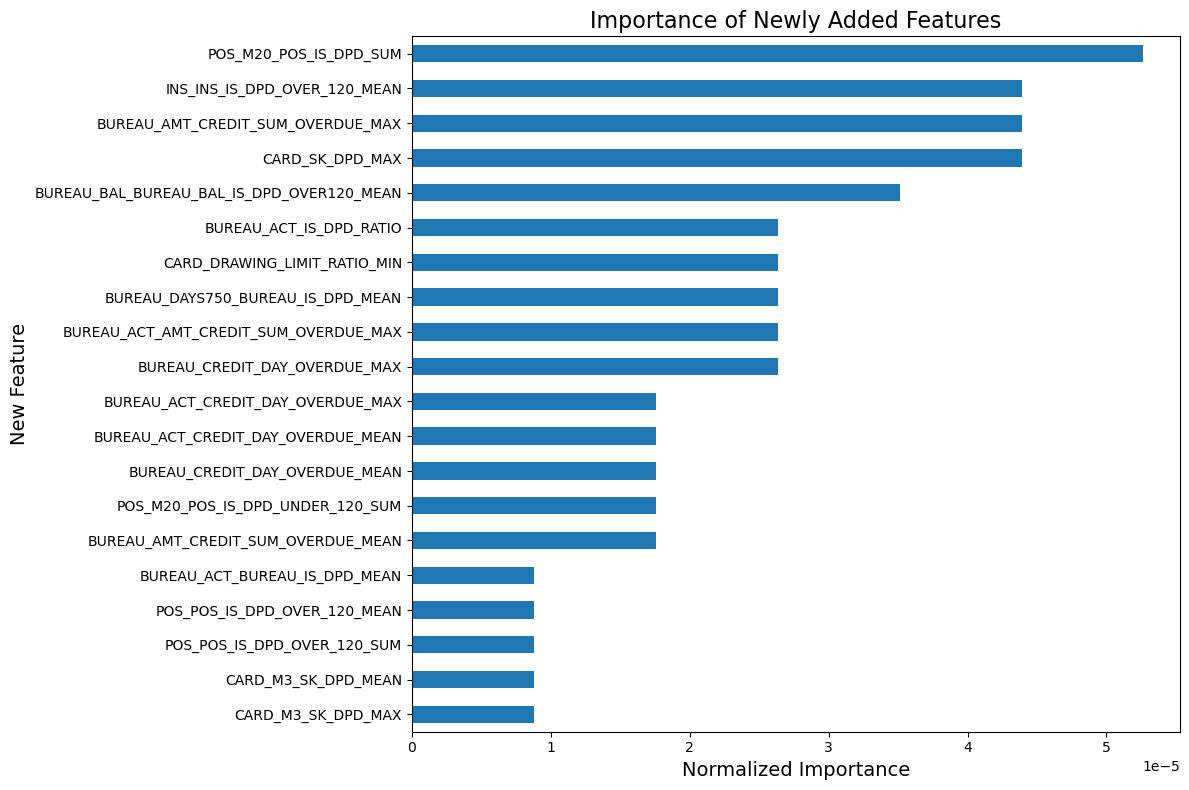

In [89]:

lgbm_feature_importances = pd.Series(clf_basline_LGBMClassifier.feature_importances_, index=X_train_encoded.columns)
normalized_lgbm_feature_importances = lgbm_feature_importances / lgbm_feature_importances.sum()
new_feature_prefixes = [
        'BUREAU_', 
        'PREV_', 
        'POS_', 
        'INS_', 
        'CARD_']
    
is_new_feature = normalized_lgbm_feature_importances.index.str.startswith(tuple(new_feature_prefixes))
new_feature_importances = normalized_lgbm_feature_importances[is_new_feature]
    
if new_feature_importances.empty:
    print("未找到任何新增的特征。请检查前缀是否正确。")
else:
    new_features_sorted = new_feature_importances[new_feature_importances > 0].sort_values(ascending=True)[:20]
        
    if new_features_sorted.empty:
        print("所有新增特征的重要性均为 0。")
    else:  
        plt.figure(figsize=(12, 8))
        new_features_sorted.plot.barh()
        plt.title('Importance of Newly Added Features', fontsize=16)
        plt.xlabel('Normalized Importance', fontsize=14)
        plt.ylabel('New Feature', fontsize=14)
        plt.tight_layout()
plt.savefig("output/newly_added_features_importance.jpg", dpi=600)